In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score


In [35]:
customer_features = pd.read_csv('preprocessed.csv')

In [36]:
X = pd.read_csv('cleaned.csv')

In [37]:
X.shape

(4338, 22)

In [38]:
X.head()

,Total_Spend,Average_Order_Value,Median_Order_Value,Maximum_Order_Value,Minimum_Order_Value,Total_Quantity,Average_Quantity,Maximum_Quantity,Minimum_Quantity,Total_Transactions,...,Average_Unit_Price,Maximum_Unit_Price,Minimum_Unit_Price,Countries,Recency,Customer_Lifetime,Spend_per_Transaction,Quantity_per_Transaction,Product_Diversity,Cancellation_Rate
0,11.253955,11.253955,11.253955,11.253955,11.253955,11.214735,11.214735,11.214735,11.214735,0.693147,...,0.712950,0.712950,0.712950,0.693147,5.789960,0,11.253955,11.214735,1.000000,0.5
1,8.368925,3.206047,2.890372,5.523858,1.798404,7.807510,2.674528,5.484797,1.098612,2.079442,...,1.293085,2.621039,0.223144,0.693147,1.098612,365,6.424406,5.864037,14.714286,0.0
2,7.494564,4.077122,3.755603,5.484797,2.653242,7.758761,4.337502,4.976734,0.693147,1.609438,...,1.911738,3.713572,0.254642,0.693147,4.330733,282,6.109936,6.373746,5.500000,0.0
3,7.472245,3.221912,2.928524,5.707110,2.033398,6.448889,2.266319,3.610918,0.693147,0.693147,...,2.228835,5.707110,0.350657,0.693147,2.995732,0,7.472245,6.448889,73.000000,0.0
4,5.815324,3.028712,3.034953,3.713572,2.251292,5.288267,2.532763,3.218876,0.693147,0.693147,...,1.577158,3.713572,0.615186,0.693147,5.739793,0,5.815324,5.288267,17.000000,0.0


## Standardization

In [39]:
#Scaling the features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Applying PCA

In [40]:
pca_full = PCA()
    
X_pca_full = pca_full.fit_transform(X_scaled)

explained_variance = (
    pca_full.explained_variance_ratio_
)

explained_variance

array([3.11869569e-01, 2.63633128e-01, 1.16162474e-01, 8.52900633e-02,
       4.58077618e-02, 4.40539010e-02, 3.23838739e-02, 2.44790355e-02,
       1.83211685e-02, 1.45737700e-02, 1.13776398e-02, 1.01017873e-02,
       6.72721513e-03, 5.48330528e-03, 4.84914328e-03, 2.39841055e-03,
       1.42431991e-03, 8.79811491e-04, 1.55659386e-04, 2.48128875e-05,
       2.81242321e-06, 3.37188531e-07])

In [41]:
cumulative_variance = np.cumsum(
    explained_variance
)

cumulative_variance

array([0.31186957, 0.5755027 , 0.69166517, 0.77695523, 0.822763  ,
       0.8668169 , 0.89920077, 0.92367981, 0.94200098, 0.95657475,
       0.96795239, 0.97805417, 0.98478139, 0.99026469, 0.99511384,
       0.99751225, 0.99893657, 0.99981638, 0.99997204, 0.99999685,
       0.99999966, 1.        ])

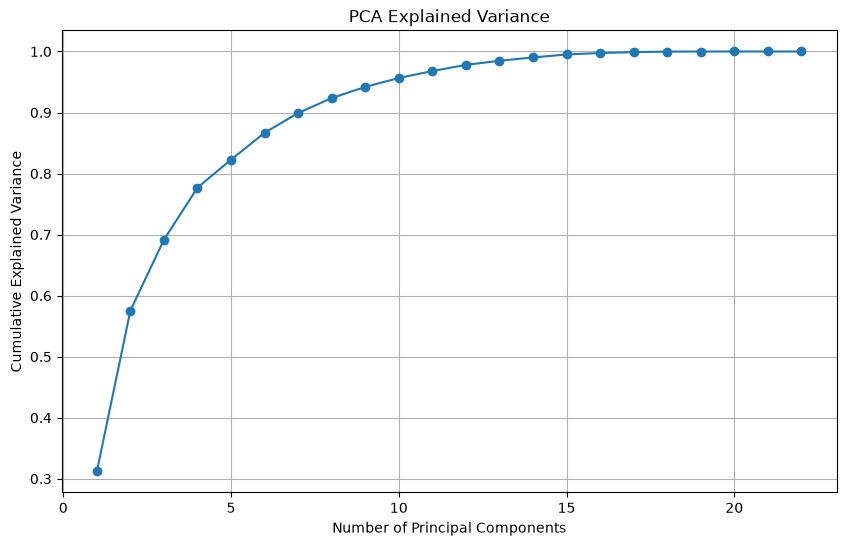

In [42]:
#Visualize the PCA
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")

plt.grid()
plt.show()

## PCA for 2D visualization

pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled)

In [44]:
print(pca_2d.explained_variance_ratio_)

print(pca_2d.explained_variance_ratio_.sum())

[0.31186957 0.26363313]
0.5755026972157193


In [45]:
pca_df = pd.DataFrame(
    X_pca_2d,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,1.694846,26.700509
1,3.920995,1.646946
2,1.728155,3.490385
3,2.395144,0.194250
4,-1.700228,-0.036311


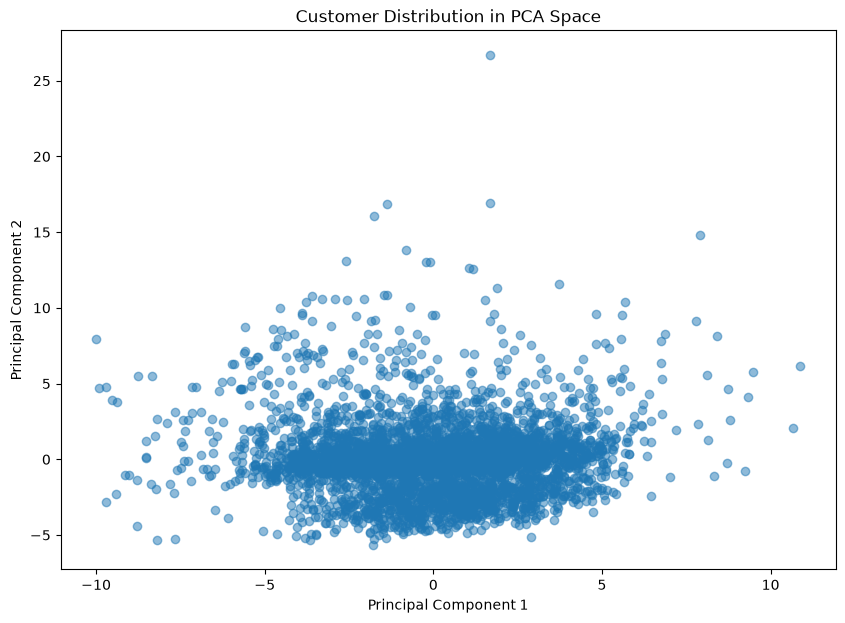

In [46]:
#Visualize the PCA
plt.figure(figsize=(10, 7))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    alpha=0.5
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Distribution in PCA Space")

plt.show()

In [47]:
#Understanding PCA components meaning
loadings = pd.DataFrame(
    pca_2d.components_.T,
    columns=["PC1", "PC2"],
    index=X.columns
)

loadings

,PC1,PC2
Total_Spend,0.342407,0.137832
Average_Order_Value,-0.034570,0.400218
Median_Order_Value,-0.063592,0.382766
Maximum_Order_Value,0.151809,0.310376
Minimum_Order_Value,-0.173481,0.315348
Total_Quantity,0.355249,0.125770
Average_Quantity,0.027538,0.382044
Maximum_Quantity,0.209415,0.262970
Minimum_Quantity,-0.130138,0.285524
Total_Transactions,0.288064,0.053924


In [48]:
loadings["PC1"].sort_values(
    ascending=False
)

Total_Quantity              0.355249
Total_Spend                 0.342407
Unique_Descriptions         0.338974
Unique_Products             0.338437
Total_Transactions          0.288064
Customer_Lifetime           0.262534
Quantity_per_Transaction    0.248457
Spend_per_Transaction       0.226322
Maximum_Quantity            0.209415
Maximum_Order_Value         0.151809
Maximum_Unit_Price          0.147995
Product_Diversity           0.120050
Cancellation_Rate           0.045803
Average_Quantity            0.027538
Countries                   0.018511
Average_Order_Value        -0.034570
Median_Order_Value         -0.063592
Average_Unit_Price         -0.068002
Minimum_Quantity           -0.130138
Minimum_Order_Value        -0.173481
Recency                    -0.213611
Minimum_Unit_Price         -0.230904
Name: PC1, dtype: float64

In [49]:
loadings["PC2"].sort_values(
    ascending=False
)

Average_Order_Value         0.400218
Median_Order_Value          0.382766
Average_Quantity            0.382044
Minimum_Order_Value         0.315348
Maximum_Order_Value         0.310376
Minimum_Quantity            0.285524
Maximum_Quantity            0.262970
Spend_per_Transaction       0.172036
Quantity_per_Transaction    0.140527
Total_Spend                 0.137832
Total_Quantity              0.125770
Minimum_Unit_Price          0.114976
Total_Transactions          0.053924
Customer_Lifetime           0.031289
Average_Unit_Price          0.026211
Cancellation_Rate           0.018402
Countries                   0.011312
Recency                    -0.003850
Maximum_Unit_Price         -0.056450
Unique_Descriptions        -0.167196
Unique_Products            -0.168242
Product_Diversity          -0.197539
Name: PC2, dtype: float64

## K-Means Clustering

### Elbow Method

In [50]:
inertia = []

K_range = range(2, 11)

for k in K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

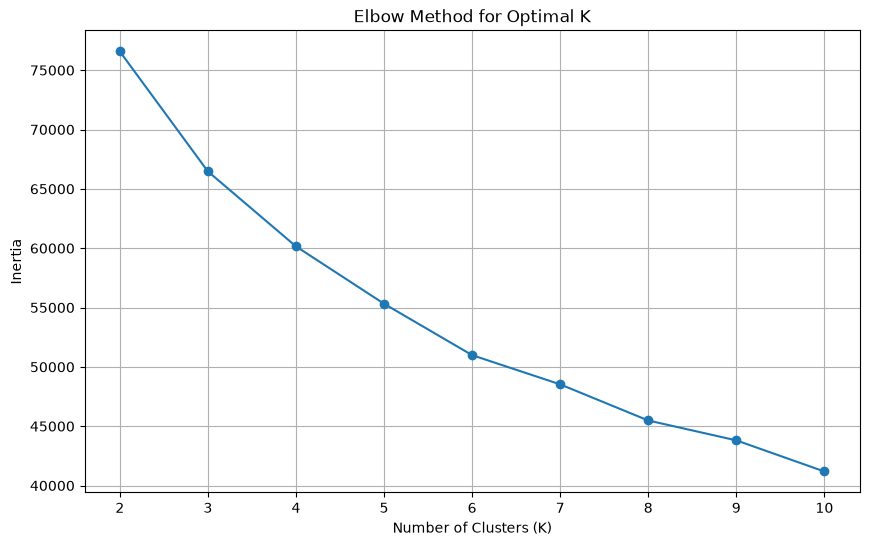

In [51]:
#Ploting the Inertia for optimal K value
plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.xticks(K_range)
plt.grid()

plt.show()

### Silhouette Score

In [52]:
silhouette_scores = []

for k i1n K_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(score)

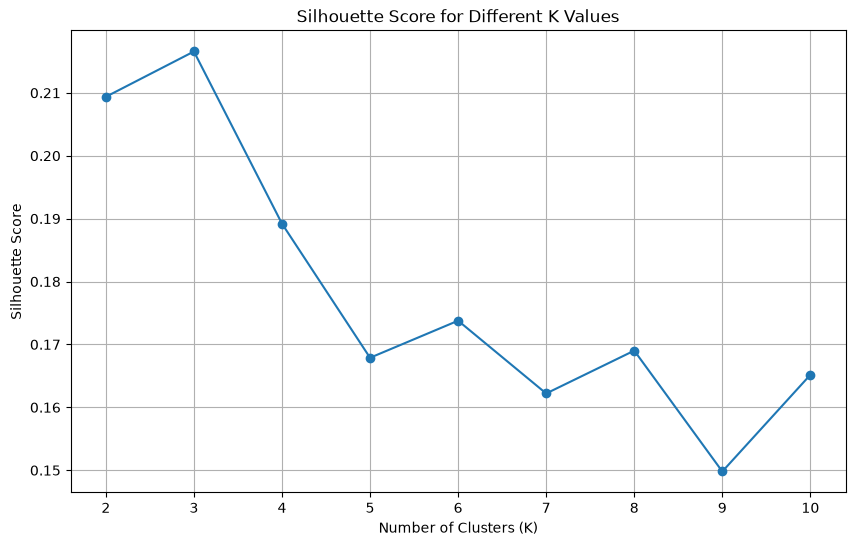

In [53]:
#Ploting the Silhouette Score for optimal K value
plt.figure(figsize=(10, 6))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.xticks(K_range)
plt.grid()

plt.show()

In [54]:
#Choosing K
results = pd.DataFrame({
    "K": list(K_range),
    "Inertia": inertia,
    "Silhouette_Score": silhouette_scores
})

results

,K,Inertia,Silhouette_Score
0,2,76574.525684,0.209367
1,3,66468.115039,0.216571
2,4,60152.800154,0.189200
3,5,55319.520067,0.167880
4,6,50988.146568,0.173774
5,7,48526.080198,0.162204
6,8,45482.495144,0.169016
7,9,43808.016073,0.149800
8,10,41184.444393,0.165176


## Train Final K-Means

In [55]:
final_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = final_kmeans.fit_predict(X_scaled)

In [56]:
customer_features["Cluster"] = clusters

## Visualize the final clusters with PCA

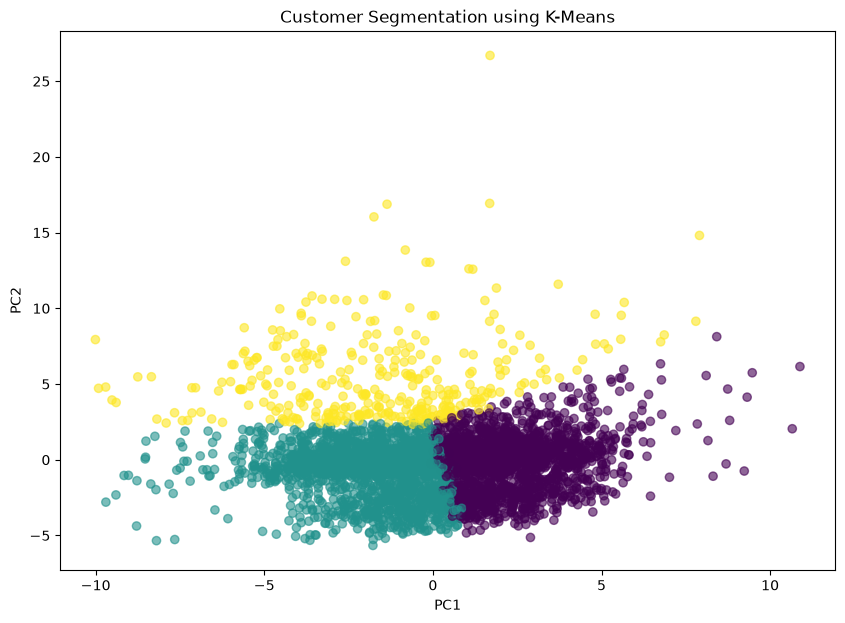

In [57]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=clusters,
    cmap="viridis",
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segmentation using K-Means")

plt.show()

## Analyze the clusters

In [58]:
cluster_profile = customer_features.groupby("Cluster").mean(
    numeric_only=True
)

cluster_profile.T

Cluster,0,1,2
CustomerID,15186.386959,15386.616219,15388.517341
Total_Spend,3557.373015,362.588818,4296.277775
Average_Order_Value,21.129322,17.501806,635.405205
Median_Order_Value,15.462648,14.406869,412.256185
Maximum_Order_Value,141.697344,48.619972,1300.086936
Minimum_Order_Value,3.778018,6.831175,337.252630
Total_Quantity,2062.644575,201.246110,2548.442197
Average_Quantity,12.553872,9.524712,438.740310
Maximum_Quantity,96.398717,31.570957,771.497110
Minimum_Quantity,1.384286,2.341348,287.976879


In [59]:
#No of customers in each cluster
cluster_size = customer_features["Cluster"].value_counts().sort_index()

cluster_size

Cluster
0    1871
1    2121
2     346
Name: count, dtype: int64

In [61]:
#Percentage customer in cluster
cluster_percentage = (
    customer_features["Cluster"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

cluster_percentage

Cluster
0    43.130475
1    48.893499
2     7.976026
Name: proportion, dtype: float64

## Create Customer Personas

In [62]:
profile_features = [
    col for col in customer_features.select_dtypes(
        include=np.number
    ).columns
    if col != "Cluster"
]

profile_scaled = customer_features.groupby("Cluster")[
    profile_features
].mean()

profile_scaled = pd.DataFrame(
    StandardScaler().fit_transform(profile_scaled),
    index=profile_scaled.index,
    columns=profile_scaled.columns
)

profile_scaled.T

Cluster,0,1,2
CustomerID,-1.414166,0.697060,0.717106
Total_Spend,0.479553,-1.391958,0.912405
Average_Order_Value,-0.700853,-0.713343,1.414195
Median_Order_Value,-0.704286,-0.709923,1.414210
Maximum_Order_Value,-0.623779,-0.787280,1.411060
Minimum_Order_Value,-0.716840,-0.697329,1.414169
Total_Quantity,0.453273,-1.386769,0.933496
Average_Quantity,-0.699582,-0.714605,1.414187
Maximum_Quantity,-0.608010,-0.801772,1.409782
Minimum_Quantity,-0.710652,-0.703556,1.414208


In [63]:
important_features = [
    "Recency",
    "Total_Spend",
    "Total_Transactions",
    "Total_Quantity",
    "Average_Order_Value",
    "Unique_Products",
    "Product_Diversity",
    "Customer_Lifetime"
]

customer_features.groupby("Cluster")[
    important_features
].mean().round(2)

,Recency,Total_Spend,Total_Transactions,Total_Quantity,Average_Order_Value,Unique_Products,Product_Diversity,Customer_Lifetime
Cluster,,,,,,,,
0,40.32,3557.37,7.36,2062.64,21.13,112.93,22.98,227.62
1,134.25,362.59,1.65,201.25,17.50,24.55,17.25,50.24
2,119.18,4296.28,3.64,2548.44,635.41,9.89,4.37,96.69


# Final Business Segmentation
| Cluster       | Persona                          | Main Behavior                           | Business Value | Recommended Strategy                      |
| ------------- | -------------------------------- | --------------------------------------- | -------------- | ----------------------------------------- |
| **Cluster 0** | 🟢 **Frequent & Diverse Buyers** | Frequent purchases, broad product range | **High**       | Loyalty, cross-sell, increase basket size |
| **Cluster 1** | 🔵 **Low-Engagement Customers**  | Low spending and activity               | **Low**        | Re-engagement, discounts, retention       |
| **Cluster 2** | 🟣 **High-Value Bulk Buyers**    | Large, expensive transactions           | **Very High**  | VIP treatment, bulk pricing, upselling    |
